# Integration of Partial Differential Equations Part 2

This week we continue our discussion of partial differential equations (PDEs). We will further explor solutiont o hyberbolic equations, focussing on the important case of finite volume methods and fluid dynamics. We will then cover the solution of parabolic equations, which will build on the iterative methods (e.g. Jacobi, Gauss-Seidel) that we have already encountered.

## 1. Conservation Laws and Finite Volume Methods

A **conservation law** in its differential form reads
$$
\frac{\partial u(t, \mathbf{x})}{\partial t} +\nabla \cdot \mathbf{F}(t, \mathbf{x}) = 0.
$$
Here, $u$ is the evolving quantity, usually expressed as a density (quantity per unit volume) and $\mathbf{F}$ is the flux of that quantity (rate per unit area per unit time).  Consider, for example, the continuity equation, which represents conservation of mass:
$$
\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{v}) = 0,
$$
where $\rho$ is the mass density and $\mathbf{v}$ is the velocity.  The fact that the right hand side of this equation is zero tells us that mass is neither being created nor destroyed but only being moved around.  One can see this more clearly by integrating the equation over volume:
$$
\frac{\partial\int\rho d^3\mathbf{x}}{\partial t} +\int  \nabla \cdot (\rho \mathbf{v}) d^3\mathbf{x}=0,
$$
where integration is caried over the same volume for each integral. Using the divergence theorem, we find
$$
\frac{\partial\int\rho d^3\mathbf{x}}{\partial t} = -\int \rho \mathbf{v} \cdot \hat{n} d S,
$$
where the integral $dS$ is take over the surface enclosing the volume. This is the integral form of the conservation relation.  In other words, the rate of change in mass of a volume is equal to the intergral of the net flux of mass out of or into the volume.  If the volumes represent simulation cells, then the mass flux into or out of one cell will be offset by mass out of or into neighboring cells.  The only exception is if the cell is on the boundary of the simulation and mass is allowed to flow into or out of the domain.  In this sense, the total mass of the simulation is conserved except for mass flow at the physical boundaries.

In some case, the right hand side of the equation may be non-zero and the equation will still be said to be in flux conservative form:
$$
\frac{\partial u(t, \mathbf{x})}{\partial t} +\nabla \cdot \mathbf{F}(t, \mathbf{x}) = S(t, \mathbf{x}),
$$
with $S$ being a source term representing the (local) creation or destruction of the quantity $u$.

In 1D our conservation law reduces to 
$$
\frac{\partial u(t, x)}{\partial t} +\frac{\partial \mathbf{F}(t, x)}{\partial x} = 0.
$$
In this case, the integral of $u$ over a fixed domain $[x_1, x_2]$
$$
  \int_{x_1}^{x_2} u(t,x)\,\mathrm{d}x
$$
is conserved, if $F(t,x_1) = F(t,x_2) = 0$.

### Finite Volume Methods

**Finite volume methods** are often used to solve hyperbolic problems because they are designed to preserve conserved quantities down to machine precision. In standard finite difference equations, the value of the variable being integrated is often thought of as being sampled at specific points labeled by integers e.g. $u_i$.  In finite volume methods, we instead think of our simulation domain as being made up of cell of given volume.  For example, in Cartesian coordinates with a uniform cell size, each cell is a rectangle with volume $\Delta x \times \Delta y \times \Delta z$ and the cell is identified by three integers (e.g. $i$, $j$, $k$).  The quantities being integrated (e.g. $u_{i,j,k}$) are now thought of as the average of the variable over the whole cell.

These cell volumes are then enclosed by cell faces, which are labeled with half integers (e.g. $i \pm 1/2$, $j\pm 1/2$, $k \pm 1/2$). The method can be written in 1D as 
$$
V_i \frac{ u_i^{n+1} - u_i^n}{\Delta t} = - (A_{i+1/2}F_{i+1/2} - A_{i-1/2} F_{i-1/2}),
$$
which follows from the integral form of the conservation law, with $u_i$ now representing the volume average of $u$ in cell $i$ and $F_{i-1/2}$ represents the flux at the interface between cell $i - 1$ and cell $i$.  In cartesian coordinates, with a uniform grid, we expect that
$$
A_{i+1/2} = A_{i-1/2} = \frac{V_i}{\Delta x}
$$
and we can write our equation in the finite difference form
$$
u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}(F_{i+1/2} - F_{i-1/2})
$$
We now update $u_i$ if we can compute $F$ at all faces. The problem of finding the flux $F_{i-1/2}$ given the left state $u_{i-1}$ and the right state $u_i$ is called the **Riemann problem**. It is most often discussed in the context of fluid dynamics, which we introduce below. There are multiple different algorithms for solving this problem, which yield results with different stability properties and different spatial convergence (e.g. first order, second order, etc.).  We can also generalize the above equation to yield implicit representations or take substeps, leading to higher order representations in time.

The computation of of $F_{i \pm 1/2}$ is often broken up into two parts.  First one reconstructs the variable of interest at the interfaces $u_{i \pm 1/2}$. For example, the value of $u_{i-1/2}$ might simply be taken as some weighted average of the $u_{i-1}$ and $u_i$.  If a higher order method is desired, one might use more cells (e.g. $u_{i-2}$, $u_{i-1}$, and $u_i$).  The method by which $u_{i \pm 1/2}$ is calculated is called the **reconstruction** method.  One the values of $u_{i \pm 1/2}$ are known, one uses some complimentary algorithm to compute $F_{i \pm 1/2}$ given $u_{i \pm 1/2}$. For simpler problems this may be combined into a single step.

### Ghost Cells and Boundary Conditions

Finite volume methods usually compute fluxes based on values of variables in neighboring cell on either side of the interface.  This means that values outside the simulation domain will have to be used on boundaries.  Most implementations approach this by having a combination of active cells and ghost cells.  **Active cells** are the ones being updated by the integration method.  **Ghost cells**, in constrast, are on the boundaries and specified by the boundary conditions.  A first order method requires at least one ghost cell and higher order methods usually require more ghost cells as they use more neighboring cells to represent the values at the interfaces.

Let's consider the following example, a domain with $N$ active cells which has two ghost cells at each end of the domain for a total of $N+4$ cells.
<table>
  <tr>
    <td colspan="2" style="text-align:center;border-right-style:solid;">ghost cells</td>
    <td colspan="5" style="text-align:center;">active cells</td>
    <td colspan="2" style="text-align:center;border-left-style:solid;">ghost cells</td>
  </tr>
  <tr>
    <td width="40em">$u_0$</td>
    <td width="40em" style="border-right-style:solid;">$u_1$</td>
    <td width="40em">$u_2$</td>
    <td width="40em">$u_3$</td>
    <td width="40em">$\dots$</td>
    <td width="40em">$u_N$</td>
    <td width="40em">$u_{N+1}$</td>
    <td width="40em" style="border-left-style:solid;">$u_{N+2}$</td>
    <td width="40em">$u_{N+3}$</td>
  </tr>
</table>

In this case, our boundary condtion must specify the value of $u_0$, $u_1$, $u_{N+2}$ and $u_{N+3}$.  For example in periodic boundary conditions we would choose
$$
u_0 = u_N, ~~ u_1 = u_{N+1}, ~~ u_{N+2} = u_2, ~~ u_{N+3} = u_3
$$

### Burger's equation revisited

Last weeek we solved Burgers equation in flux conservative form as
$$
\frac{\partial u}{\partial t}+\frac{\partial}{\partial x}\left(\frac{u^2}{2}\right)=0,
$$
Since this is conservative, we can use a finite volume representation of the form
$$
u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}(F_{i+1/2} - F_{i-1/2})
$$

We can specify $F_{i \pm 1/2}$ using a simple upwind method e.g.
$$
F_{i-1/2} = \frac{(u_{i-1}^n)^2}{2} ~~ {\rm if}~~ u_{i-1/2}^n > 0,
$$
or
$$
F_{i-1/2} = \frac{(u_i^n)^2}{2} ~~ {\rm if}~~ u_{i-1/2}^n \le 0,
$$
and $u_{i-1/2}= (u_{i-1}+u_i)/2$.

Lets try implementing below. I will give you the functions to intialize and obtain the fluxes.

In [1]:
import numpy as np

def initial_gaussian(x):
    """ Initialize profile """
    
    return 0.2 + 0.8 * np.exp(-0.5 * x**2)

def riemann_upwind(ul, ur):
    """ solve rieman problem for burgers using upwind """

    # use the average ul and ur to determine direction
    ua = 0.5*(ul+ur)
    if ua > 0:
        return ul**2/2
    else:
        return ur**2/2

## **Student Completion**

Complete the function below

In [90]:
def burgers_fv(nx, dt0=None, cfl=1, dtout=0.5):
    """ Integrate Burger's equation with the finite volume method """
    
    # set up our steps in time and space
    xl = -10
    xr = 10
    tstart = 0
    tend = 40
                                                   
    # compute domain
    dx = (xr-xl)/(nx-1)
    x = np.arange(xl, xr+dx, dx)[:nx]

    # initialize field
    u = initial_gaussian(x)
    
    # set output grid
    nt = int((tend-tstart)/dtout)+2
    uout = np.zeros((nx,nt))
    uout[:, 0] = u
    tout = np.zeros(nt)
    tout[0] = tstart

    nout = 0
    t = tstart
    F = np.zeros(nx-1)
    while t < tend:
        if dt0 is None:
            dt = cfl*np.min(dx/abs(u))
        else:
            dt = dt0
        # boundary conditions with single ghost zone

        ## Student completion -- implement periodic boundary condition
        
        # compute the flux
        for i in range(nx-1):
            F[i] = riemann_upwind(u[i], u[i+1])
        # update u given F
        
        ## Student completion -- update u given F

        t += dt

        if t >= nout*dtout:
            nout += 1
            uout[:, nout] = u
            tout[nout] = t
            
    return x, tout, uout 

In [2]:
# MY SOLUTION -- REMOVE
def burgers_fv(nx, dt0=None, cfl=1, dtout=0.5):
    """ Integrate Burger's equation with the finite volume method """
    
    # set up our steps in time and space
    xl = -10
    xr = 10
    tstart = 0
    tend = 40
                                                   
    # compute domain
    dx = (xr-xl)/(nx-1)
    x = np.arange(xl, xr+dx, dx)[:nx]

    # initialize field
    u = initial_gaussian(x)
    
    # set output grid
    nt = int((tend-tstart)/dtout)+2
    uout = np.zeros((nx,nt))
    uout[:, 0] = u
    tout = np.zeros(nt)
    tout[0] = tstart

    nout = 0
    t = tstart
    F = np.zeros(nx-1)
    while t < tend:
        if dt0 is None:
            dt = cfl*np.min(dx/abs(u))
        else:
            dt = dt0
        # boundary conditions with single ghost zone
        u[0] = u[-2]
        u[-1] = u[1]
        
        # compute the flux
        for i in range(nx-1):
            F[i] = riemann_upwind(u[i], u[i+1])
        # update u given F
        u[1:-1] -= dt / dx * (F[1:] - F[:-1])
        t += dt

        if t >= nout*dtout:
            nout += 1
            uout[:, nout] = u
            tout[nout] = t
            
    return x, tout, uout 

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython import display 

fig, ax = plt.subplots()

# run the integration
nx = 201
x, t, u = burgers_fv(nx, cfl=1)
nt = t.shape[0]

def animate(i):
    ax.clear()
    # Get the point from the points list at index i
    ax.plot(x, u[:, i])
    # Set the x and y axis to display a fixed range
    ax.set_xlim([-10, 10])
    ax.set_ylim([0, 1.2])


ani = FuncAnimation(fig, animate, frames=80, interval=40, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

for i in range(0, nt, 4):
    print("time: ",t[i],"sum: ",u[1:-1,i].sum()) #exclude boundaries

time:  0.0 sum:  59.8530261970481
time:  1.5001119952318245 sum:  59.853026197048095
time:  3.5112637781429545 sum:  59.853026197048095
time:  5.562513471663235 sum:  59.85302619704809
time:  7.578319093636076 sum:  59.85302619704808
time:  9.627962342071651 sum:  59.853026197048095
time:  11.534438426486727 sum:  59.853026197048095
time:  13.540406546514307 sum:  59.85302619704808
time:  15.639271568947194 sum:  59.853026197048095
time:  17.509052418574253 sum:  59.85302619704808
time:  19.60344018398064 sum:  59.85302619704808
time:  21.599130466928827 sum:  59.85302619704808
time:  23.65029819390375 sum:  59.85302619704809
time:  25.577928061361586 sum:  59.853026197048095
time:  27.548895890540148 sum:  59.85302619704808
time:  29.561791061592327 sum:  59.85302619704808
time:  31.61477868762564 sum:  59.85302619704809
time:  33.51494583592199 sum:  59.85302619704809
time:  35.640813137787 sum:  59.853026197048095
time:  37.6052448257686 sum:  59.85302619704808
time:  39.59880760099

We see that a sum over all $u$ on the active (evolving) grid yields the same value to machine precision. The finite volume approach enforces the conservative nature of the PDE.

What if we had differenced it in another way?  One could also have performed a simple finite difference on $u$ directly and then multiplied by $u$ e.g.:
$$
\left(\frac{\partial u}{\partial x}\right)^n =\frac{u_{i}^n-u_{i-1}^n}{\Delta x} ~~ {\rm if}~~ u_{i}^n>0,
$$
$$
\left(\frac{\partial u}{\partial x}\right)^n=\frac{u_{i+1}^n-u_{i}^n}{\Delta x} ~~ {\rm if}~~ u_{i}^n<0.
$$
The update then follows from
$$
u_i^{n+1}=u_i^n-u_i^n \Delta t \left(\frac{\partial u}{\partial x}\right)^n
$$

The operator corresponding to the spatial derivative is formally the same mathematically, but as we have already learned, that does not mean the discretization will yield the same results.  Lets try it out.

In [4]:
import numpy as np

def initial_gaussian(x):
    """ Initialize profile """
    
    return 0.2 + 0.8 * np.exp(-0.5 * x**2)

def burgers_upwind_nc(nx, dt0=None, cfl=1, dtout=0.5):
    """ Integrate Burger's equation with the Upwind method """
    
    # set up our steps in time and space
    xl = -10
    xr = 10
    tstart = 0
    tend = 40
                                                   
    # compute domain
    dx = (xr-xl)/(nx-1)
    x = np.arange(xl, xr+dx, dx)[:nx]

    # initialize field
    u = initial_gaussian(x)
    up = np.copy(u)

    # set output grid
    nt = int((tend-tstart)/dtout)+2
    uout = np.zeros((nx,nt))
    uout[:, 0] = u
    tout = np.zeros(nt)
    tout[0] = tstart

    nout = 0
    t = tstart
    F = np.zeros_like(u)
    while t < tend:
        if dt0 is None:
            dt = cfl*np.min(dx/abs(u))
        else:
            dt = dt0
        # compute boundary conditions
        u[0] = u[-2]
        u[-1] = u[1]

        # update u
        for i in range(1, nx-1):
            if u[i] > 0:
                dudx = (up[i]-up[i-1])/dx
            elif u[i] < 0:
                dudx = (up[i+1]-up[i])/dx   
            else:
                dFdx = 0.
            u[i] = up[i]*(1 - dt*dudx)
        t += dt
        up[:] = u
        
        if t >= nout*dtout:
            nout += 1
            uout[:, nout] = u
            tout[nout] = t
            
    return x, tout, uout 

In [5]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython import display 

fig, ax = plt.subplots()

# run the integration
nx = 201
x, t, u = burgers_upwind_nc(nx, cfl=1)
nt = t.shape[0]

def animate(i):
    ax.clear()
    # Get the point from the points list at index i
    ax.plot(x, u[:, i])
    # Set the x and y axis to display a fixed range
    ax.set_xlim([-10, 10])
    ax.set_ylim([0, 1.2])


ani = FuncAnimation(fig, animate, frames=80, interval=40, repeat=False)
video = ani.to_html5_video()
html = display.HTML(video)
display.display(html)
plt.close()

for i in range(nt):
    print("time: ",t[i],"sum: ",u[1:-1,i].sum())


time:  0.0 sum:  59.8530261970481
time:  0.1 sum:  59.82470235498818
time:  0.500017418752249 sum:  59.710722631944705
time:  1.0000935305982512 sum:  59.55946718681372
time:  1.5002758448156117 sum:  59.383828722475904
time:  2.0007462179924955 sum:  59.15684046135481
time:  2.502541256782922 sum:  58.83462831860471
time:  3.011080894006707 sum:  58.399723350903756
time:  3.535330407821551 sum:  57.89601297229512
time:  4.079382429311347 sum:  57.37743812557439
time:  4.53151565361271 sum:  56.96303830467832
time:  5.119021674165177 sum:  56.457134050212716
time:  5.606586563404202 sum:  56.072947325932695
time:  6.1102137286726395 sum:  55.70605694226632
time:  6.629952618198155 sum:  55.35693656841778
time:  7.029923295738695 sum:  55.109661344712464
time:  7.577749714627406 sum:  54.79049628981731
time:  8.141559446638503 sum:  54.487592465612664
time:  8.575382729719026 sum:  54.26969935453778
time:  9.017236048721973 sum:  54.06164258733297
time:  9.620974119882362 sum:  53.79538

The evolution looks qualitatively similar in the two approaches, but we see that the amplitude is lower and the profile hasn't shifted as far in the last case.  We see via the sum over $u$, that $u$ is decreasing with time, indicating that amplitude is dropping. Choosing your discretization to enforce conservation can have a significant impact!  Since conservations laws are so important in physics (e.g. cons. of mass, momentum, and energy), this feature makes finite volume algorithms very popular.

## 2. Fluid Dynamics

Lets now introduce the important case of fluid dynamics.  Many of the systems we study in astrophysics can be accurately modeled as fluids. This includes systems ranging from interstellar gas to stars themselves.  As a result, evolution of the fluid equations (often coupled to other physical processes) are one of the most common applications of numerical simulations in astronomy.

We often use the approximation of an ideal fluid, which can be described by the **Euler equations**, which in 1D have the form:
\begin{equation}
  \frac{\partial}{\partial t}
  \left(\begin{array}{c}
    \rho\\
    \rho u\\
    E
  \end{array}\right) +
  \frac{\partial}{\partial x}
  \left(\begin{array}{c}
    \rho u\\
    \rho u^2 + p\\
    (E + p)u
  \end{array}\right) = 0,
\end{equation}

where $\rho$ is the density, $u$ is the velocity, $E$ is the *total* energy density (internal and kinetic), and $p$ is the pressure.
This is a system of *three* conservation laws for density, linear momentum, and energy, respectively.
The system is closed by the **equation of state** where the internal energy is equal to $p/(\gamma-1)$ so that the total energy is
$$
E = \frac{p}{\gamma - 1} + \frac{1}{2}\rho u^2,
$$
where $\gamma$ is the adiabatic index.

In a finite volume method for this case, then, each cell contains *three* variables, i.e., a vector.
The equations can be written as
$$
\mathbf{U}_i^{n+1} = \mathbf{U}_i^n - \frac{\Delta t}{\Delta x}(\mathbf{F}_{i+1/2} - \mathbf{F}_{i-1/2})
$$
where $\mathbf{U}=(\rho, \rho u, E)$ are the **conserved variables** and $\mathbf{F}$ are the corresponding 1D fluxes of the conserved variables. The conserved variables are those actually being integrated by the code. In this case the correspond to the fluid mass density, momentum density, and total energy density.  In many cases, the Riemann solvers take the **primitive variables** as inputs. In fluid dynamics, these usuall correspond to the mass density, velocity, and pressure e.g. $\mathbf{W} = (\rho, u, p)$.

In fluid dynamics, the Riemann problem is usually treated as follows: one assume a discontinuity in the variables at the interface between two cells.  One uses a reconstruction method to determine the left and right states on either side of this discontinuity, and then solves for how such a discontinuity would evolve. The details require a bit more work to understand, so we will skip over them here. This approach provides accurate evolution, even when shocks develop in the flow.  There are many methods to solve the problem efficiently but approximately. It can be shown that approximate solutions can be almost as good as the more exact solution, but are considerably less copmutationally expensive. We provide here one solution, called the **Roe solver**, which uses a linear approximation of the system while correctly capturing the shock structure if shocks are present.  If you are interested in understanding these solution better, you can find more information here:

https://www.ita.uni-heidelberg.de/~dullemond/lectures/num_fluid_2011/Chapter_6.pdf

https://www.ita.uni-heidelberg.de/~dullemond/lectures/num_fluid_2011/Chapter_7.pdf

Since coding up the Roe solver is a bit more complicated, I wll just give it to you, but review the code to understand what it is doing.

Finally, we note that we still have a time-step constraint, which is correspond to the CFL condition.  In this case, we are assuming that the Riemann problems on opposite sides of the cell are independent for the duration of the time step so that the fluxes can be computed independently.  This is accomplished by determining the fastest propagation speed, which corresponds to the sum of advection velociy and gas sound speed: $c_{\rm max} = |u + \sqrt{\gamma p/\rho}|$.  We then require that
$$
\Delta t = C \Delta x / c_{\rm max}
$$
with $C$ being the CFL numbera and $C \le 1$.

In [6]:
import numpy as np

def rsolver(wl, wr, gamma=5/3):
    """
    Returns the flux vector given the left state wl and the right state wr.  The state vectors
    are organized as
    
    wl[0]: left mass density; wr[0]: right mass density;
    wl[1]: left velocity;     wr[1]: right velocity;
    wl[2]: left pressure;     wr[2]: right pressure;
        
    The returned flux vector is for the conserved variables (rho, rho*u, E).
    """
    
    # Decompose the states.
    rhol, ul, pl = wl
    rhor, ur, pr = wr
    
    # Compute Roe-averaged state
    sqrtdl = np.sqrt(rhol)   
    sqrtdr = np.sqrt(rhor)
    isdlpdr = 1 / (sqrtdl + sqrtdr)
    
    roed = sqrtdl * sqrtdr
    roevx = (sqrtdl * ul + sqrtdr * ur) * isdlpdr
    el = pl / (gamma - 1) + 0.5 * rhol * ul**2
    er = pr / (gamma - 1) + 0.5 * rhor * ur**2
    # enthalpy
    roeh = ((el + pl) / sqrtdl + (er + pr) / sqrtdr) * isdlpdr
    
    # Compute sound speed in L,R, and Roe-averaged state
    cl = np.sqrt(gamma * pl / rhol)
    cr = np.sqrt(gamma * pr / rhor)
    q = max([roeh - 0.5 * roevx**2, 0.0])
    a = np.sqrt((gamma - 1) * q)

    # Compute the max/min wave speeds based on L/R and Roe-averaged values
    al = min([roevx - a, ul - cl])
    ar = max([roevx + a, ur + cr])
    bp = max([ar, 0.0])
    bm = min([al, 0.0])
        
    # Compute L/R fluxes along the lines bm/bp: F_L - (S_L)U_L; F_R - (S_R)U_R
    fl = np.zeros(3,)
    fr = np.zeros(3,)
    
    fl[0] = rhol * (ul - bm)
    fr[0] = rhor * (ur - bp)
    fl[1] = rhol * ul * (ul - bm) + pl
    fr[1] = rhor * ur * (ur - bp) + pr
    fl[2] = el * (ul - bm) + pl * ul
    fr[2] = er * (ur - bp) + pr * ur
    
    if bp != bm:
        tmp = 0.5 * (bp + bm) / (bp - bm)
    else:
        tmp = 0
    return 0.5 * (fl + fr) + (fl - fr) * tmp

### Application: Shock-tube

Let's try this on a specific example. Consider a **shock tube**, in which a 1D pipe is separated by a divider at $x = 0$ into two compartments and the divider is suddenly removed at $t = 0$.  Write your initial conditions as follows.

\begin{aligned}
  \rho = 3, u = 0, p = 3, \quad & \textrm{if}\ x < 0,\\
  \rho = 1, u = 0, p = 1, \quad & \textrm{if}\ x > 0.
\end{aligned}
The case where each state is uniform and the flow velocity is initially zero everywhere can be solved analytically (or semi-analytically with a root find) and is commonly used for testing hydro code e.g. the Sod shock tube: https://en.wikipedia.org/wiki/Sod_shock_tube

Note that this system is not periodic, so we need to used different boundary conditions than we did above for solving Burger's equation. Let's try the following
$$
U_0= U_1, ~~ U_{N+2} = U_{N+1}.
$$
In other words, we copy the values in the last active cell before boundary out into the ghost cell(s).  This boundary condition is an example of an open boundary condition.

We will also use a computational domain of $-2 \le x \le 2$ and run the code up to $t = 1$.

In [7]:
import numpy as np

# Function to convert conserved variables to primative variables.
def cons2prim(cons, gamma):
    """ Convert (rho, mom, Etot) to (rho, u, p) """
    rho, mom, Etot = cons
    u = mom / rho
    p = (gamma - 1) * (Etot - 0.5 * rho * u**2)
    return np.vstack((rho, u, p))

def initial_condition(x, nh, gamma):
    """ Compute the initial profile """
    nxt = x.shape[0]
    U = np.zeros((nh, nxt))
    U[0, np.where(x < 0)] = 3.0
    U[0, np.where(x >= 0)] = 1.0
    U[2, np.where(x < 0)] = 3.0 / (gamma - 1)
    U[2, np.where(x >= 0)] = 1.0 / (gamma - 1)
    return U

def boundary_conditions(U, nh, ng):
    for ih in range(nh):
        U[ih][0:ng]=U[ih][ng]
        U[ih][-ng:]=U[ih][-ng-1]

## **Student Completion**

Complete the finite volume integrator below by setting the timestep and updating the conserved variables given the flux.

In [6]:
def euler_fv(nx, cfl=0.8, dtout=0.2):
    """ Integrate Eulers's equations with the finite volume method """

    # set adiabatic index
    gamma = 5./3.
    
    # define some method parameters
    nh = 3 # number of conserved variables
    ng = 1 # number of ghost zones
    
    # set up our steps in time and space
    xmin = -2  # left boundary
    xmax = 2  # right boundary
    tstart = 0
    tend = 1
                                                   
    # compute domain -- assign coordinates to the cell *centers*
    dx = (xmax - xmin) / nx
    x = xmin + (np.arange(nx + 2 * ng) - ng + 0.5) * dx 

    # initialize variables
    U = initial_condition(x, nh, gamma) # conserved
    W = cons2prim(U, gamma) #primitive
    
    # set output grid
    nt = int((tend-tstart)/dtout)+1
    Wout = np.zeros((nh, nx+2*ng, nt))
    Wout[:, :, 0] = W
    tout = np.zeros(nt)
    tout[0] = tstart

    nout = 1
    t = tstart
    F = np.zeros((nh, nx+2*ng+1))
    while t < tend:
        # set ghost cells
        boundary_conditions(U, nh, ng)

        # Find the maximum characteristic speed to set time step.

        ## Student completion -- set csmax used for the timestep
        csmax = 
        
        dt = cfl * dx / csmax
        
        # compute the flux
        for i in range(ng, ng+nx+1):
            F[:,i] = rsolver(W[:,i-1], W[:,i], gamma)

        # update U given F

        ## Student completion -- your code here

        W = cons2prim(U, gamma)
        t += dt

        if t >= nout*dtout:
            Wout[:, :, nout] = W
            tout[nout] = t
            nout += 1

    return x, tout, Wout 

In [8]:
# MY SOLUTION -- REMOVE
def euler_fv(nx, cfl=0.8, dtout=0.2):
    """ Integrate Eulers's equations with the finite volume method """

    # set adiabatic index
    gamma = 5./3.
    
    # define some method parameters
    nh = 3 # number of conserved variables
    ng = 1 # number of ghost zones
    
    # set up our steps in time and space
    xmin = -2  # left boundary
    xmax = 2  # right boundary
    tstart = 0
    tend = 1
                                                   
    # compute domain -- assign coordinates to the cell *centers*
    dx = (xmax - xmin) / nx
    x = xmin + (np.arange(nx + 2 * ng) - ng + 0.5) * dx 

    # initialize variables
    U = initial_condition(x, nh, gamma) # conserved
    W = cons2prim(U, gamma) #primitive
    
    # set output grid
    nt = int((tend-tstart)/dtout)+1
    Wout = np.zeros((nh, nx+2*ng, nt))
    Wout[:, :, 0] = W
    tout = np.zeros(nt)
    tout[0] = tstart

    nout = 1
    t = tstart
    F = np.zeros((nh, nx+2*ng+1))
    while t < tend:
        # set ghost cells
        boundary_conditions(U, nh, ng)

        # Find the maximum characteristic speed to set time step.
        csmax = max(abs(W[1,:]) + np.sqrt(gamma * W[2,:] / W[0,:]))
        dt = cfl * dx / csmax
        
        # compute the flux
        for i in range(ng, ng+nx+1):
            F[:,i] = rsolver(W[:,i-1], W[:,i], gamma)

        # update U given F
        for ih in range(nh):
            for ix in range(ng, nx+ng):
                U[ih, ix] -= dt / dx * (F[ih, ix+1] - F[ih, ix])

        W = cons2prim(U, gamma)
        t += dt

        if t >= nout*dtout:
            Wout[:, :, nout] = W
            tout[nout] = t
            nout += 1

    return x, tout, Wout 

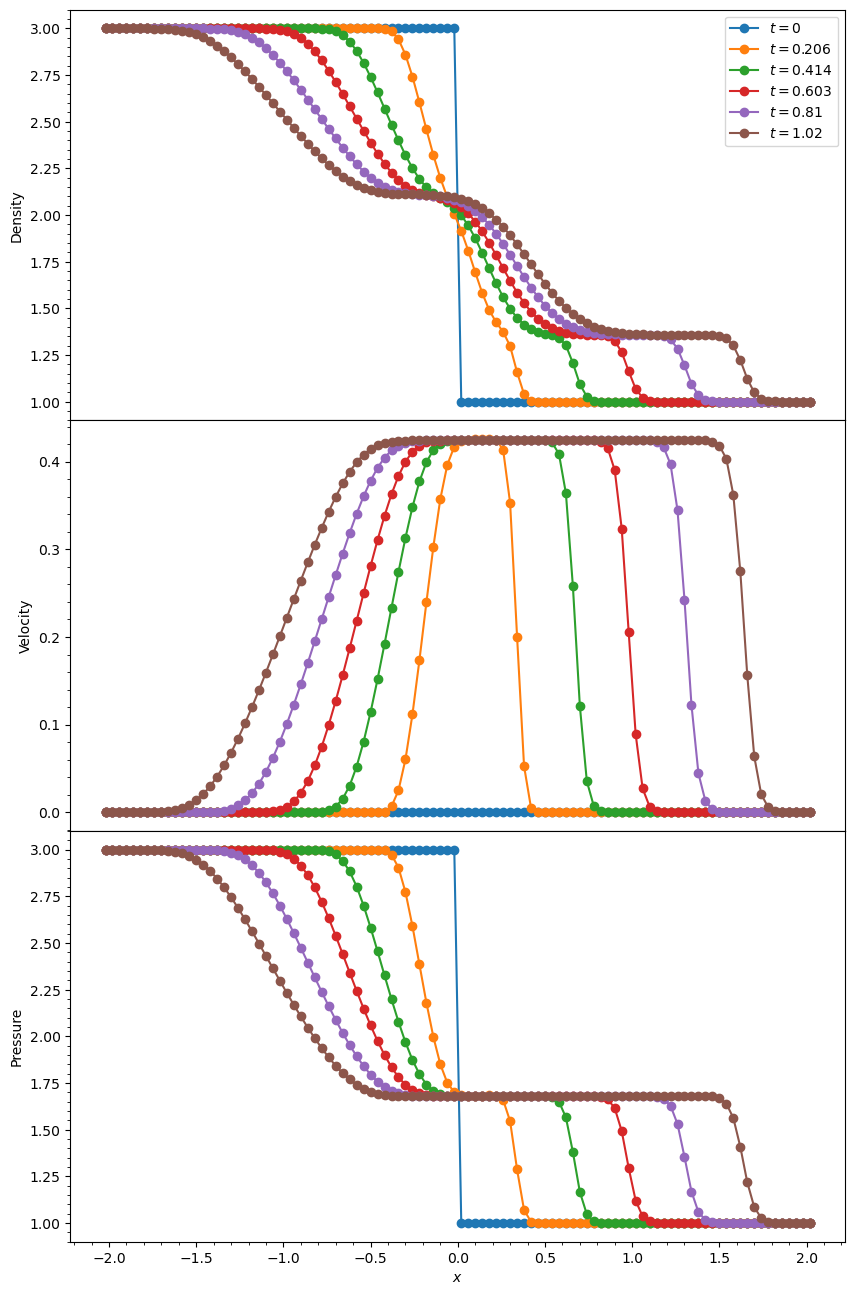

In [11]:
%matplotlib inline
# run the integration
nx = 100
x, t, W = euler_fv(nx, cfl=0.8)
nt = t.shape[0]

# Initiate the plot.
fig, axes = plt.subplots(nrows=3, sharex=True, figsize=(10,16))
fig.subplots_adjust(hspace=0)
for i in range(3):
    for j in range(nt):
        axes[i].plot(x, W[i, :, j], 'o-', label=r"$t = {:.3G}$".format(t[j]))
    axes[i].minorticks_on()
axes[-1].set_xlabel(r"$x$")
axes[0].set_ylabel(r"Density")
axes[1].set_ylabel(r"Velocity")
axes[2].set_ylabel(r"Pressure")

axes[0].legend();

## 3. Solving Elliptic Equations

A classic example of elliptic equations (that we have already solved) is Poisson's equation:
$$
\nabla^2 \phi = k \rho
$$
where $k$ depends on whether we are considering a gravitational potential or an electromagnetic potential.  An astrophysically interesting example is when $\Phi$ is the gravitational potential, $\rho$ is the mass density, and $k = 4\pi G$, where $G$ is Newton's constant.

We have already solved some variation of this equation in 1D using the Jacobi and Gauss-Seidel methods.  Let's now try this in 2D.

### 2D Jacobi

For simplicity, we discretize the equation in 2D assuming the spacing in the $x$ and $y$ directions are the same $\Delta x=\Delta y$
$$
\frac{1}{\Delta x^2}(\Phi_{i+1,j}+\Phi_{i-1,j}+\Phi_{i,j+1}+\Phi_{i,j-1}-4 \Phi_{i,j})=4 \pi G\rho_{i,j}
$$
Then we can use neigboring grids to calculate $\Phi_{i,j}$ with
$$
\Phi_{i,j}^{n+1}=\frac{1}{4}(\Phi_{i+1,j}^n+\Phi_{i-1,j}^n+\Phi_{i,j+1}^n+\Phi_{i,j-1}^n)-\Delta x^2 \pi G \rho_{i,j},
$$
where $n$ labels the iteration number.

Let's solve this for a density distribution of the form
$$
\rho = \frac{1}{4\pi G}\sin(\pi x)*\sin(\pi y)
$$
over the domain $x=(0,1)$ and $y=(0,1)$.

This has an analytic solution that we can use to check our result:
$$
\Phi(x, y) = -\frac{\sin(\pi x)\sin(\pi y)}{2\pi^2}
$$

In [12]:
def analytic_solution(X, Y):
    """ analtyics solution for testing """
    return -np.sin(np.pi*X)*np.sin(np.pi*Y)/np.pi**2/2
    
def density(x, y):
    """ mass density """
    X, Y = np.meshgrid(x, y)
    return np.sin(np.pi*X)*np.sin(np.pi*Y)

def error(phi1, phi2):
    """
    Normalized relative change in phi between two iterations
    """
    TINY = 1e-10 # avoids potential NaN
    dphi = np.abs((phi2-phi1)[1:-1,1:-1]/(0.5*np.abs(phi1+phi2)+TINY)[1:-1,1:-1])
    return dphi.sum()

def iterate_jacobi(nx, itermax=10000, eps=1.e-3):
    """
    Solve Poisson's equation using Jacobi
    """

    # initialize grid and rhs on this process
    x0 = 0
    x1 = 1
    ny = nx
    y0 = 0
    y1 = 1
    
    # set up calculation grid
    x = np.linspace(x0, x1, nx)
    y = np.linspace(y0, y1, ny) 
    dx = x[1]-x[0]
    
    phi = np.zeros((nx, ny))
    phinew = np.zeros_like(phi)
    rho = density(x, y)

    err = 10*eps # ensure while executes at least once
    iterations = 0
    while err > eps:
        iterations += 1

        for i in range(1, nx-1):                                                
            for j in range(1, ny-1): 
                phinew[i, j] = 0.25*(phi[i-1, j]+phi[i+1, j]+phi[i, j-1]+phi[i, j+1]-dx*dx*rho[i, j])
        
        err = error(phi, phinew)
        phi = np.copy(phinew)

        if iterations == itermax:
            break

    print("Total iteration: {0} {1:.3e}".format(iterations, err))

    return x, y, phi

Total iteration: 4116 9.993e-04
Average Error:  2.599767883220163e-06


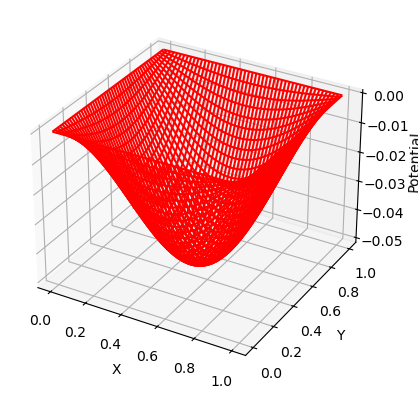

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

nx = 50
x, y, phi = iterate_jacobi(nx)
X, Y = np.meshgrid(x, y)
sol = analytic_solution(X, Y)
print("Average Error: ",np.average(np.abs(phi-sol)))

# plot result as wireframe
ax = plt.figure().add_subplot(projection='3d')
ax.plot_wireframe(X, Y, phi, color = 'r') # Red wireframe
ax.set_xlabel('X')                                     
ax.set_ylabel('Y')
ax.set_zlabel('Potential');

### 2D Gauss-Seidel

Now lets implement Gauss-Seidel.  We have
$$
\Phi_{i,j}^{n+1}=\frac{1}{4}(\Phi_{i+1,j}^n+\Phi_{i-1,j}^{n+1}+\Phi_{i,j+1}^n+\Phi_{i,j-1}^{n+1})-\Delta x^2 \pi G \rho_{i,j}.
$$
Here $\Phi_{i,j}^{n+1}$ appears on the right hand side because these values are computed earlier in the loop. In other words, we use the updated value of $\Phi$ as soon as it becomes available.  This is even easier than Jacobi in that we don't have store a copy of the previous iteration of $\phi^n$, we simply update as we go through the loop.  (We still do so here to make it easy evaluate the relative change in $\Phi$ for convergence.)

In [15]:
def iterate_gs(nx, itermax=10000, eps=1.e-3):
    """
    Solve Poisson's equation using Gauss-Seidel
    """

    # initialize grid and rhs on this process
    x0 = 0
    x1 = 1
    ny = nx
    y0 = 0
    y1 = 1
    
    # set up calculation grid
    x = np.linspace(x0, x1, nx)
    y = np.linspace(y0, y1, ny) 
    dx = x[1]-x[0]
    
    phi = np.zeros((nx, ny))
    rho = density(x, y)

    err = 10*eps # ensure while executes at least once
    iterations = 0
    while err > eps:
        iterations += 1
        phinew = np.copy(phi)
        for i in range(1, nx-1):                                                
            for j in range(1, ny-1): 
                phi[i, j] = 0.25*(phi[i-1, j]+phi[i+1, j]+phi[i, j-1]+phi[i, j+1]-dx*dx*rho[i, j])
        
        err = error(phi, phinew)

        if iterations == itermax:
            break

    print("Total iteration: {0} {1:.3e}".format(iterations, err))

    return x, y, phi

Total iteration: 2228 9.963e-04
Average Error:  4.68453980716984e-06


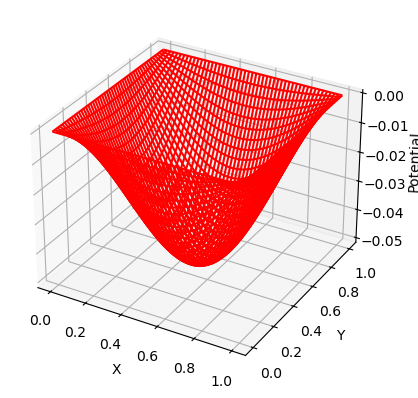

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

nx = 50
x, y, phi = iterate_gs(nx)
X, Y = np.meshgrid(x, y)
sol = analytic_solution(X, Y)
print("Average Error: ",np.average(np.abs(phi-sol)))

# plot result as wireframe
ax = plt.figure().add_subplot(projection='3d')
ax.plot_wireframe(X, Y, phi, color = 'r') # Red wireframe
ax.set_xlabel('X')                                     
ax.set_ylabel('Y')
ax.set_zlabel('Potential');

As expected from previous experience, this converges faster by about a factor of two over Jacobi.

### Succesive Over-relaxation (SOR)

The SOR algorithm is best understood by rewriting Gauss-Seidel in two steps. We first compute the difference:
$$
\Delta \Phi_{i,j} =\frac{1}{4}(\Phi_{i+1,j}^n+\Phi_{i-1,j}^{n+`}+\Phi_{i,j+1}^n+\Phi_{i,j-1}^{n+1})-\Delta x^2 \pi G \rho_{i,j} - \Phi_{i,j}^n,
$$
and then use the difference to update $\Phi$:
$$
\Phi_{i,j}^{n+1}=\Phi_{i,j}^n+\Delta \Phi_{i,j}.
$$
This identical to the expresion above. In SOR, the first step to compute the difference is the same, but we assume that a bigger change will lead to faster convergence so we use
$$
\Phi_{i,j}^{n+1}=\Phi_{i,j}^n+\omega\Delta \Phi_{i,j},
$$
with $1 \le \omega \le 2$.

## **Student Completion**

Update the GS solver to implement SOR. You should only need to change one line of code. Note that $\omega$ is now an argument of the function.

In [ ]:
def iterate_sor(nx, omega, itermax=10000, eps=1.e-3):
    """
    Solve Poisson's equation using SOR
    """

    # initialize grid and rhs on this process
    x0 = 0
    x1 = 1
    ny = nx
    y0 = 0
    y1 = 1
    
    # set up calculation grid
    x = np.linspace(x0, x1, nx)
    y = np.linspace(y0, y1, ny) 
    dx = x[1]-x[0]
    
    phi = np.zeros((nx, ny))
    rho = density(x, y)

    err = 10*eps # ensure while executes at least once
    iterations = 0
    while err > eps:
        iterations += 1
        phinew = np.copy(phi)
        for i in range(1, nx-1):                                                
            for j in range(1, ny-1): 
                ## Student compltion -- add your code here

        err = error(phi, phinew)

        if iterations == itermax:
            break

    print("Total iteration: {0} {1:.3e}".format(iterations, err))

    return x, y, phi

In [17]:
## MY SOLUTION -- REMOVE
def iterate_sor(nx, omega, itermax=10000, eps=1.e-3):
    """
    Solve Poisson's equation using SOR
    """

    # initialize grid and rhs on this process
    x0 = 0
    x1 = 1
    ny = nx
    y0 = 0
    y1 = 1
    
    # set up calculation grid
    x = np.linspace(x0, x1, nx)
    y = np.linspace(y0, y1, ny) 
    dx = x[1]-x[0]
    
    phi = np.zeros((nx, ny))
    rho = density(x, y)

    err = 10*eps # ensure while executes at least once
    iterations = 0
    while err > eps:
        iterations += 1
        phinew = np.copy(phi)
        for i in range(1, nx-1):                                                
            for j in range(1, ny-1): 
                dphi = 0.25*(phi[i-1, j]+phi[i+1, j]+phi[i, j-1]+phi[i, j+1]-dx*dx*rho[i, j])-phi[i, j]
                phi[i, j] += dphi*omega

        err = error(phi, phinew)

        if iterations == itermax:
            break

    print("Total iteration: {0} {1:.3e}".format(iterations, err))

    return x, y, phi

Total iteration: 587 9.909e-04
Average Error:  1.5955182879090205e-06


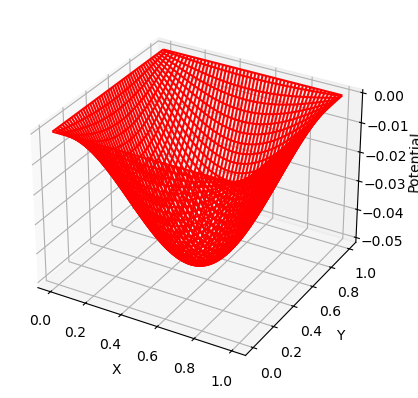

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

nx = 100
x, y, phi = iterate_sor(nx, 1.9)
X, Y = np.meshgrid(x, y)
sol = analytic_solution(X, Y)
print("Average Error: ",np.average(np.abs(phi-sol)))

# plot result as wireframe
ax = plt.figure().add_subplot(projection='3d')
ax.plot_wireframe(X, Y, phi, color = 'r') # Red wireframe
ax.set_xlabel('X')                                     
ax.set_ylabel('Y')
ax.set_zlabel('Potential');

SOR can greatly speed up convergence for some problems, but choosing the optimal value for $\omega$ can be tricky as the optimal choice is problem dependent.  Making $\omega$ too large can slow convergence.

## **Student Completion**

Double the number of grid points in each direction from `nx=50` to `nx=100`.  What happens to the number of iterations it takes?  You should find that it approximately double.  Increasing the resolution of the data slows the convergence and requires more iteration.  Why is this?

Methods like Jacobi and Gauss-Seidel smooth the result on short length scales (high spatial frequencies) because the difference only depends on neighboring cells. If one starts with a noisy solution that has approximately the right shape on large scales, one will find rapid convergence.  If, however, the bulk of the initial guess deviates from the true solution on large spatial scales, then convergence will take a long time. We need an algorithm that takes into account the large length scales (lower spatial frequencies).

## 4. Mutligrid Method

As discussed above, if we want to speed up convergence, we need algorithms that operate simultaneously on both large and small lengths scales. One of the most popular and powerful ways of doing this is to implement the multigrid method.  The idea of the multigrid method is that you can coarsen your grid so that there are fewer points in each direction and use a standard solution algorithm (e.g. Gauss-Seidel, Jacobi etc.) to update (smooth) the grid on increasingly coarser levels, until you come down to some coarsest reasonable matrix.  Then you start making the grid finer again, performing smoothing on each level until you return to the original level.  If you do this correctly, you will have similar covergence at all spatial scales.

A description can be found at: https://en.wikipedia.org/wiki/Multigrid_method. I reproduce the figure from that here:
![figure1](Multigrid_Visualization.png)
to illustrate the concept.

There are several parts to the algorithm.  First you need to make the finer/coarser grids. The operation for making a coarser grid is called **restriction** and the operation of making a finer grid is called **prolongation**.  (The same terms are used in adaptive mesh refinement schemes.)

### Prolongation

For a 2D array the prolongated grid will have a larger number of points (usually by a factor of 2) in both dimensions, relative to the previous grid.  For example, at $N \times N$ grid would be average to produce a $2N \times 2N$ grid. One can approach this a number of ways, but the most common is the following.  Assume that the $N \times N$ grid is label by points $v_{i,j}$ where both $i$ and $j$ run from 0 to $N-1$ and finer grid by $u_{i,j}$ where both $i$ and $j$ run from 0 to $2N-1$.  Then we can comput the values of the finer grid by 
first sweeping in one direction, averaging with neighboring points so that $u_{2i,2j}=v_{i,j}$ and
$$
u_{2i,2j+1} = \frac{1}{2}\left(v_{i,j}+v_{i,j+1}\right)
$$
Next sweep in the orthogonal direction with
$$
u_{2i+1,2j} = \frac{1}{2}\left(v_{i,j}+v_{i+1,j}\right)
$$
And then for the remaining points on the corners we have
$$
u_{2i+1,2j+1} = \frac{1}{4}\left(v_{i,j}+v_{i+1,j}+v_{i,j+1}+v_{i+1,j+1}\right)
$$

### Restriction

For a 2D array the restricted grid will be smaller (usually by a factor of 2) in both dimensions.  For example, at $N \times N$ grid would be average to produce a $N/2 \times N/2$ grid. The restriction operation should invert the prolongation operatation.  For the prologonation method described above, the inverse process has form
$$
v_{i,j} = \frac{1}{4}\left(u_{2i,2j} + \frac{1}{2}\left[u_{2i-1,2j}+u_{2i+1,2j}+u_{2i,2j-1}+u_{2i,2j+1} \right]+
\frac{1}{4}\left[ u_{2i-1,2j-1}+u_{2i+1,2j-1}+u_{2i-1,2j+1}+u_{2i+1,2j+1}\right]\right)
$$

### V-Cycles

Now we need to describe the process of how we actually do the solution.  First, it is important to understand that we are not simply solving the original equation (e.g. Poisson's equation) at each coarse or fine level.  This would not work.  The differences between levels would prevent the result from converging.  The multigrid approach instead performs restriction and prolongation on the **residual**:
$$
r = \rho - \nabla^2 \Phi
$$
which in our method is discretized as
$$
r_{i,j} = \rho_{i,j} - \frac{1}{4 \Delta x^2}\left( \Phi_{i+1,j} + \Phi_{i-1,j} + \Phi_{i,j+1} + \Phi_{i,j-1} - 4*\Phi_{i,j}\right)
$$
The residual should get smaller as we converge to the correct answer.

If we write the correct solution as $\Phi^*$, what we want on each iteration is to find $\Delta \Phi$ so that
$$
\Phi^* = \Phi +\delta \Phi
$$
where $\Phi$ is our current approximation. Since by definition $\nabla^2 \Phi^* = \rho$, we can see that $\delta \Phi$ is the given by
$$
\nabla^2 \delta \Phi = \rho - \nabla^ \Phi = r.
$$
This has the same form as our original equation but with $\Phi \rightarrow \delta \Phi$ and $\rho \rightarrow r$.

Hence for a V-cycle that only drops a single level, we would:
1. Compute the residual
2. Restrict the residual to a coarser grid
3. Use a smoothing algorithm (e.g. Gauss-Seidel) to estimate $\delta \Phi$, starting from a guess of 0
4. Prolongate $\delta \Phi$ to the finer grid and then add $\Phi = \Phi + \delta \Phi$

In practice, the method converges faster if we continue restriction to a very coarse level (e.g. $\sim 4 \times 4$) before starting the prolongation steps.  In the V-Cycle, one always starts at the finest grid level (the one you want to solve the problem on) and continue restricting until you reach the coarsets level, then you continue prolongating until you reach the finest level again. There are also variants of the method (e.g. W-Cycles) that stop prolongation at an intermediate level, begin restricting again, then continute prolongation after reaching the coarsest level. These W-Cycles can converge faster for some problems, but we will consider the V-cycle below.

Each iteration of the algorithm is then the performance of an entire V-Cycle (or W-Cycle, etc.).  If the V-Cycles are exectued correctly, the algorithm can converge in relatively few iterations.

## In Class Exercises

Lets implement the multigrid algorithm.  The full algorithm is rather involved and would be a challenge to do in our limited class time.  So, instead, I will give you the pieces for prolongation, restriction, and the smoothing aglorithm (SOR/Gauss-Seidel).

You need to complete the vcycle function.

In [19]:
def solve_sor(phi, rho, n, dx, omega=1, nit=1):
    """
    Update this level using SOR method. By default, omega=1, which corresponds
    to Gauss-Seidel
    inputs:
    phi (ndarray): array on which the solution is updated
    rho (ndarray): source term on right hand side of poisson equation
    n (int): dimension of the array in each direction
    dx (float): grid space in both dimensions (assumed uniform)
    omega (float): value between 1 and 2 for over-relaxation (default 1)
    nit (int): number of iterations to perform on this level (default 3)
    
    outputs:
    res (ndarray): residual on this level
    phi (ndarray): update array
    """

    res = np.zeros((n, n))
    # n is number of iterations to do at each level
    for it in range(nit):  
        maxerr = 0.
        for i in range(1, n-1):                                                
            for j in range(1, n-1):
                dphi = 0.25*(phi[i+1, j] + phi[i-1, j] + phi[i, j+1] + phi[i, j-1]
                             - rho[i, j]*dx**2) - phi[i, j]
                if maxerr < abs(dphi):
                    maxerr = abs(dphi)
                phi[i, j] += omega*dphi

    # compute residual of Poisson's equation
    for i in range(1, n-1):                                                
        for j in range(1, n-1):
            res[i,j] = rho[i,j] - 0.25*(phi[i+1, j] + phi[i-1, j] + phi[i, j+1] + phi[i, j-1]
                                        - 4*phi[i, j])/dx**2
    # return residual and updated phi
    return res, phi

def restrict(arr, n):
    """ 
    Restrict to coarser grid
    inputs:
    arr (ndarray): square array that one wants to restrict
    n (int): length of the array in each dimension

    output:
    arrc (ndarray): restricted square array with dimensions:
                    int((n-1)/2+1) ~ n/2
    """

    # enforce that grid must be odd -- keeps things simple
    assert(n % 2 == 1)
    # compute dimension of coarser grid and create
    nc = int((n-1)/2 + 1)
    arrc = np.zeros((nc, nc))
    # perform restriction
    for i in range(nc): 
        arrc[i, 0] = arr[i*2, 0]
        arrc[i, -1] = arr[i*2, -1]
    for j in range(nc): 
        arrc[0, j] = arr[0, j*2]
        arrc[-1, j] = arr[-1, j*2]
    for i in range(1, nc-1): 
        for j in range(1, nc-1):
            arrc[i, j] = 0.25*(arr[2*i, 2*j]
                               + 0.5  * (arr[2*i-1, 2*j] + arr[2*i+1, 2*j]
                                         + arr[2*i, 2*j-1]+ arr[2*i, 2*j+1])
                               + 0.25 * (arr[2*i-1, 2*j-1] + arr[2*i-1, 2*j+1]
                                         + arr[2*i+1, 2*j-1]+ arr[2*i+1, 2*j+1]))
    return arrc


def prolongate(arr, n):
    """
    Prolongate to finer grid
    inputs:
    arr (ndarray): square array that one wants to prolongate
    n (int): length of the array in each dimension

    output:
    arrf (ndarray): prolongated square array with dimensions:
                    n*2-1
    """

    # compute dimension of finer grid
    nf = 2*n-1
    arrf = np.zeros((nf, nf))
    # perform prolongation by averaging
    for i in range(n): 
        for j in range(n):
            arrf[2*i, 2*j] = arr[i, j]
            if i < n-1:
                arrf[2*i+1, 2*j] = 0.5*(arr[i, j] + arr[i+1, j])
            if j < n-1:
                arrf[2*i, 2*j+1] = 0.5*(arr[i, j] + arr[i, j+1])
            if (i < n-1) and (j < n-1):
                arrf[2*i+1, 2*j+1] = 0.25*(arr[i, j] + arr[i+1, j]
                                           + arr[i, j+1] + arr[i+1, j+1])
    return arrf

In [224]:
def vcycle(arr, rho, size, dx):
    """ perform one V cycle iteration """

    # solve using SOR on current grid
    res, arr = solve_sor(arr, rho, size, dx)  
    if(size < 8):
        # stop recursion if size is small enough
        return arr       
        
    # restrict residual to coarser grid
    res2h = restrict(res, size)
    n2h = int((size-1)/2+1)
    e2h = np.zeros((n2h, n2h))
    # call vcycle recursively on residual
    e2h = vcycle(e2h, res2h, n2h, dx*2)

    # prolongate residual back to finer grid and
    # add to arr on this level

    e2 = prolongate(e2h, n2h)
    arr += e2
    res, arr = solve_sor(arr, rho, size, dx)
    return arr

In [20]:
# MY SOLUTION -- REMOVE
def vcycle(arr, rho, size, dx):
    """ perform one V cycle iteration """

    # solve using SOR on current grid
    res, arr = solve_sor(arr, rho, size, dx)  
    if(size < 8):
        # stop recursion if size is small enough
        return arr       
        
    # restrict residual to coarser grid
    res2h = restrict(res, size)
    n2h = int((size-1)/2+1)    
    e2h = np.zeros((n2h, n2h))
    # call vcycle recursively on residual
    e2h = vcycle(e2h, res2h, n2h, 2*dx)

    # prolongate residual back to finer grid and
    # add to arr on this level
    e2 = prolongate(e2h, n2h)
    arr += e2

    res, arr = solve_sor(arr, rho, size, dx)

    return arr

For this problem lets try the limit of Laplace's equation ($\rho = 0$) with a non-zero potential on the $x=0$ boundary.

In [21]:
def iterate_mg(nx, itermax=30, eps=1.e-3):
    """
    Solve Poisson's equation using multigrid solver
    """

    # initialize grid and rhs on this process
    x0 = 0
    x1 = 1
    ny = nx
    y0 = 0
    y1 = 1
    
    # set up calculation grid
    x = np.linspace(x0, x1, nx)
    y = np.linspace(y0, y1, ny) 
    dx = x[1]-x[0]
    #X, Y = np.meshgrid(x, y)
    #sol = analytic_solution(X, Y)
    sol = np.zeros((nx,ny))
    
    phi = np.zeros((nx, ny))
    #print("initial: ",error(phi, sol))
    rho = np.zeros((nx,ny))
    #rho = density(x, y)
    #phi[1:-1,1:-1] = 1.
    #print(phi)
    phi[:,0] = 100
    
    err = 10*eps # ensure while executes at least once
    iterations = 0
    while err > eps:
        iterations += 1
        phinew = np.copy(phi)
        phi = vcycle(phi, rho, nx, dx)

        err = error(phi, phinew)
        print("err: ", err)

        if iterations == itermax:
            break

    print("Total iteration: {0} {1:.3e}".format(iterations, err))

    return x, y, phi

err:  7937.9999948701725
err:  2372.5955133602656
err:  1296.5584395871986
err:  841.55397082889
err:  592.6705417809101
err:  437.5312342835873
err:  332.94575284785464
err:  258.7096810263171
err:  204.0815718449144
err:  162.81120679277473
err:  131.0092813051075
err:  106.12726208988101
err:  86.42557508225454
err:  70.67709255642673
err:  57.9925368832451
err:  47.712917971066396
err:  39.340698560424755
err:  32.49429123593956
err:  26.877125006532836
err:  22.25609657206882
err:  18.44623256600798
err:  15.2995617690283
err:  12.696902385456
err:  10.541706846318128
err:  8.755384412241206
err:  7.27370229452153
err:  6.043985578909701
err:  5.022916898540117
err:  4.174792112953098
err:  3.470126749171518
err:  2.8845351351728006
err:  2.397823591262945
err:  1.9932531217787468
err:  1.656937370286632
err:  1.3773492583782958
err:  1.1449154747324712
err:  0.9516823420371916
err:  0.7910399344431539
err:  0.6574939103772999
err:  0.5464765535411096
err:  0.45419011547473254
err

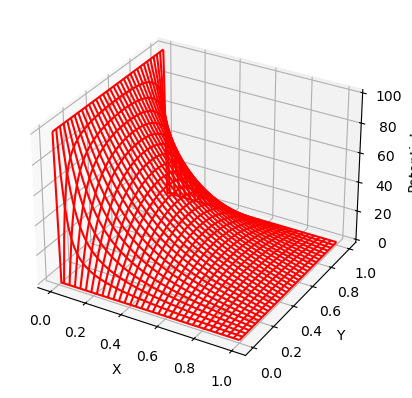

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

nx = 65
x, y, phi = iterate_mg(nx, itermax=50)
X, Y = np.meshgrid(x, y)
#sol = analytic_solution(X, Y)
#print("Average Error: ",np.average(np.abs(phi-sol)))

# plot result as wireframe
ax = plt.figure().add_subplot(projection='3d')
ax.plot_wireframe(X, Y, phi, color='r') # Red wireframe
ax.set_xlabel('X')                                     
ax.set_ylabel('Y')
ax.set_zlabel('Potential')
plt.show()